# AF3008 — Assignment 4: Experiments, Results & Analysis
## Explainable Ensemble Learning for Credit Card Fraud Detection
### Using SHAP and LIME: A Trust-Centered Regulatory Compliance Framework

**Student:** Sumyyah Saeed &nbsp;|&nbsp; **ID:** 23i-5567 &nbsp;|&nbsp; **Section:** FT(A)  
**Instructor:** Dr. Usama Arshad &nbsp;|&nbsp; **Course:** AF3008  

---

## ⚠️  BEFORE YOU RUN — Do this first

**1. Download the dataset**  
Go to → https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
Click **Download** → you get `creditcard.csv` (143 MB). A free Kaggle account is required.

**2. Upload to this Colab session**  
- In the left sidebar click the 📁 **folder icon**  
- Click the ⬆️ **upload button** (paper with upward arrow)  
- Select `creditcard.csv` from your computer  
- Wait until the file appears in the file list (progress bar at bottom)

**3. Run everything**  
Click **Runtime → Run all** (or press `Ctrl + F9`)  
The Stacking Ensemble takes ~3–5 minutes. Do not close the browser tab.

**4. Get your outputs**  
When complete:  
- Open the 📁 `graphs/` folder in the Files panel  
- Right-click each `.jpg` file → **Download**  
- Read the output of **Cell 12** — copy those numbers into your LaTeX `[FILL]` markers

---

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — Install required libraries
# (Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn are pre-installed in Colab)
# ═══════════════════════════════════════════════════════════════════════════
!pip install shap lime imbalanced-learn xgboost --quiet
print('✓ Installation complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✓ Installation complete.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — Imports and global style configuration
# IEEE-publication-quality matplotlib settings
# ═══════════════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import lime
import lime.lime_tabular

# ─── Fixed seed ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ─── Output folder ────────────────────────────────────────────────────────
os.makedirs('/content/graphs', exist_ok=True)

# ─── IEEE-compliant plot style ────────────────────────────────────────────
# These settings produce publication-ready figures:
# - Times-equivalent serif font matches IEEEtran body text
# - Minimum 8pt labels remain legible at column width (3.5")
# - Clean white background, thin grid lines, no chart junk
IEEE = {
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size':          9,
    'axes.titlesize':     10,
    'axes.labelsize':     9,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'legend.fontsize':    8,
    'legend.framealpha':  0.85,
    'axes.linewidth':     0.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linewidth':     0.5,
    'lines.linewidth':    1.6,
    'patch.linewidth':    0.6,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.05,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
}
plt.rcParams.update(IEEE)

# ─── Color palette (colorblind-safe, IEEE-appropriate) ────────────────────
COLORS = {
    'LR':      '#2166AC',   # steel blue
    'RF':      '#4DAC26',   # forest green
    'XGB':     '#D6604D',   # terracotta
    'Stack':   '#762A83',   # deep purple
    'base_f1': '#2166AC',   # dashed baseline
    'base_auc':'#4DAC26',
    'shap':    '#1A5276',
    'pearson': '#922B21',
    'neutral': '#555555',
}
MODEL_COLORS = list(COLORS.values())[:4]

def save_jpeg(path, quality=95):
    """Save current figure as 300 DPI JPEG."""
    plt.savefig(path, dpi=300, format='jpeg',
                bbox_inches='tight', pad_inches=0.05,
                pil_kwargs={'quality': quality, 'optimize': True})

print('✓ Imports and IEEE style configured.')
print(f'  Matplotlib version: {matplotlib.__version__}')

✓ Imports and IEEE style configured.
  Matplotlib version: 3.10.0


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — Load and verify dataset
# ═══════════════════════════════════════════════════════════════════════════
df = pd.read_csv('/content/creditcard.csv')

print('=== DATASET VERIFICATION (must match paper claims) ===')
print(f'  Total rows:     {len(df):,}          (expected: 284,807)')
print(f'  Fraud cases:    {df["Class"].sum():,}            (expected: 492)')
print(f'  Fraud rate:     {df["Class"].mean()*100:.3f}%       (expected: 0.172%)')
print(f'  Features:       {df.shape[1]-1}              (expected: 30)')
print(f'  Missing values: {df.isnull().sum().sum()}              (expected: 0)')
print()

assert len(df) == 284807,      'Row count mismatch — wrong file?'
assert df['Class'].sum() == 492, 'Fraud count mismatch — wrong file?'
print('✓ All assertions passed. Correct dataset loaded.')

=== DATASET VERIFICATION (must match paper claims) ===
  Total rows:     284,807          (expected: 284,807)
  Fraud cases:    492            (expected: 492)
  Fraud rate:     0.173%       (expected: 0.172%)
  Features:       30              (expected: 30)
  Missing values: 0              (expected: 0)

✓ All assertions passed. Correct dataset loaded.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — Preprocessing
# As stated in A3 Section IV-A:
#   (1) log(Amount + 1) transformation
#   (2) Z-score normalisation of Amount and Time
# ═══════════════════════════════════════════════════════════════════════════
# Step 1: Log-transform Amount
df['Amount'] = np.log1p(df['Amount'])

# Step 2: Z-score normalise Amount and Time
sc = StandardScaler()
df[['Amount', 'Time']] = sc.fit_transform(df[['Amount', 'Time']])

X = df.drop('Class', axis=1)
y = df['Class']
FEATURE_NAMES = X.columns.tolist()  # V1-V28, Time, Amount (30 total)

print('✓ Preprocessing complete.')
print(f'  Amount after transform — mean: {X["Amount"].mean():.6f}  std: {X["Amount"].std():.6f}')
print(f'  Time  after transform — mean:  {X["Time"].mean():.6f}   std: {X["Time"].std():.6f}')

✓ Preprocessing complete.
  Amount after transform — mean: 0.000000  std: 1.000002
  Time  after transform — mean:  -0.000000   std: 1.000002


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — Stratified 80/20 split → SMOTE on training partition ONLY
# As stated in A3 Section IV-C:
#   SMOTE applied exclusively to training set to prevent data leakage.
#   Test set retains original 0.172% fraud ratio throughout.
# ═══════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('=== TRAIN-TEST SPLIT ===')
print(f'  Training set:  {len(X_train):,} rows  | Fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'  Test set:      {len(X_test):,}  rows  | Fraud: {y_test.sum():,}  ({y_test.mean()*100:.3f}%)')
print(f'  Test fraud %:  {y_test.mean()*100:.3f}% — original ratio preserved ✓')
print()

# SMOTE on training partition ONLY
sm = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('=== AFTER SMOTE (training set only) ===')
print(f'  SMOTE training: {len(X_train_sm):,} rows | Fraud: {y_train_sm.sum():,}')
print(f'  Class balance: {(y_train_sm==0).sum():,} legit : {(y_train_sm==1).sum():,} fraud (1:1)')
print('  Test set unchanged ✓')

=== TRAIN-TEST SPLIT ===
  Training set:  227,845 rows  | Fraud: 394 (0.173%)
  Test set:      56,962  rows  | Fraud: 98  (0.172%)
  Test fraud %:  0.172% — original ratio preserved ✓

=== AFTER SMOTE (training set only) ===
  SMOTE training: 454,902 rows | Fraud: 227,451
  Class balance: 227,451 legit : 227,451 fraud (1:1)
  Test set unchanged ✓


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — Feature Selection Strategies (FSS)
# FSS0: All 30 features (used for main Phase 1 training)
# FSS1: Top-20 by SHAP (computed after initial model in Phase 2)
# FSS2: Top-20 by Pearson correlation (computed here)
# ═══════════════════════════════════════════════════════════════════════════
# FSS2: Pearson top-20
corr_with_target = (
    pd.concat([X_train, y_train], axis=1)
    .corr()['Class']
    .abs()
    .drop('Class')
    .sort_values(ascending=False)
)
TOP20_PEARSON = corr_with_target.nlargest(20).index.tolist()

print('=== FEATURE SELECTION ===')
print(f'  FSS0: All {len(FEATURE_NAMES)} features')
print(f'  FSS2: Top-20 by Pearson: {TOP20_PEARSON[:5]} ... (+15 more)')
print(f'  FSS1: Top-20 by SHAP — computed after model training (Phase 2)')

=== FEATURE SELECTION ===
  FSS0: All 30 features
  FSS2: Top-20 by Pearson: ['V17', 'V14', 'V12', 'V10', 'V3'] ... (+15 more)
  FSS1: Top-20 by SHAP — computed after model training (Phase 2)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — Train all 4 models and compute metrics
# As stated in A3 Section IV-D:
#   MT0: Logistic Regression (interpretable baseline)
#   MT1: Random Forest (bagging, 100 trees)
#   MT2: XGBoost (gradient boosting, 100 estimators)
#   MT3: Stacking Ensemble (RF + XGB → LR meta-learner, 5-fold CV)
# Training on: FSS0 (all 30 features) + RT1 (SMOTE)
# ═══════════════════════════════════════════════════════════════════════════
MODEL_DEFS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED,
        class_weight='balanced', n_jobs=-1, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=SEED,
        n_jobs=-1, class_weight='balanced', max_depth=None
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=SEED,
        eval_metric='logloss', verbosity=0,
        use_label_encoder=False, n_jobs=-1
    ),
    'Stacking Ensemble': StackingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(
                n_estimators=100, random_state=SEED,
                n_jobs=-1, class_weight='balanced')),
            ('xgb', XGBClassifier(
                n_estimators=100, random_state=SEED,
                eval_metric='logloss', verbosity=0,
                use_label_encoder=False, n_jobs=-1))
        ],
        final_estimator=LogisticRegression(
            max_iter=1000, random_state=SEED),
        cv=5, n_jobs=-1, passthrough=False
    )
}

RESULTS   = {}   # metric dictionaries
TRAINED   = {}   # fitted model objects

print('Training models on SMOTE data (FSS0 — all 30 features)...')
print('Stacking Ensemble uses 5-fold CV — this takes 3–5 minutes.\n')

for mname, model in MODEL_DEFS.items():
    print(f'  [{mname}]', end=' ', flush=True)
    model.fit(X_train_sm, y_train_sm)

    yp  = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:, 1]
    cm  = confusion_matrix(y_test, yp)

    RESULTS[mname] = {
        'f1':        round(f1_score(y_test, yp), 4),
        'auc':       round(roc_auc_score(y_test, ypr), 4),
        'precision': round(precision_score(y_test, yp, zero_division=0), 4),
        'recall':    round(recall_score(y_test, yp), 4),
        'cm':        cm,
        'y_pred':    yp,
        'y_proba':   ypr,
    }
    TRAINED[mname] = model
    r = RESULTS[mname]
    print(f'done   F1={r["f1"]:.4f}   AUC={r["auc"]:.4f}')

print('\n✓ All models trained.')

Training models on SMOTE data (FSS0 — all 30 features)...
Stacking Ensemble uses 5-fold CV — this takes 3–5 minutes.

  [Logistic Regression] done   F1=0.1088   AUC=0.9696
  [Random Forest] done   F1=0.8586   AUC=0.9794
  [XGBoost] done   F1=0.7736   AUC=0.9806
  [Stacking Ensemble] done   F1=0.8410   AUC=0.9838

✓ All models trained.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — Identify best model and print results summary
# ═══════════════════════════════════════════════════════════════════════════
BEST = max(RESULTS, key=lambda m: RESULTS[m]['f1'])
BEST_MODEL = TRAINED[BEST]

print('='*68)
print('PHASE 1 RESULTS — Copy into LaTeX Table')
print('='*68)
print(f'{"Model":25s}  {"F1":>7}  {"AUC":>7}  {"Precision":>10}  {"Recall":>7}')
print('-'*68)
for mname, r in RESULTS.items():
    flag = '  ← BEST MODEL' if mname == BEST else ''
    print(f'{mname:25s}  {r["f1"]:7.4f}  {r["auc"]:7.4f}  {r["precision"]:10.4f}  {r["recall"]:7.4f}{flag}')
print('-'*68)
print(f'{"Baseline RF  [Iqbal+2025]":25s}  {0.9159:7.4f}  {"—":>7}  {"—":>10}  {"—":>7}')
print(f'{"Baseline XGB [Iqbal+2025]":25s}  {"—":>7}  {0.9997:7.4f}  {"—":>10}  {"—":>7}')
print()

cm = RESULTS[BEST]['cm']
print(f'Best model: {BEST}')
print(f'  TN={cm[0][0]:,}   FP={cm[0][1]:,}   FN={cm[1][0]:,}   TP={cm[1][1]:,}')

PHASE 1 RESULTS — Copy into LaTeX Table
Model                           F1      AUC   Precision   Recall
--------------------------------------------------------------------
Logistic Regression         0.1088   0.9696      0.0578   0.9184
Random Forest               0.8586   0.9794      0.8817   0.8367  ← BEST MODEL
XGBoost                     0.7736   0.9806      0.7193   0.8367
Stacking Ensemble           0.8410   0.9838      0.8454   0.8367
--------------------------------------------------------------------
Baseline RF  [Iqbal+2025]   0.9159        —           —        —
Baseline XGB [Iqbal+2025]        —   0.9997           —        —

Best model: Random Forest
  TN=56,853   FP=11   FN=16   TP=82


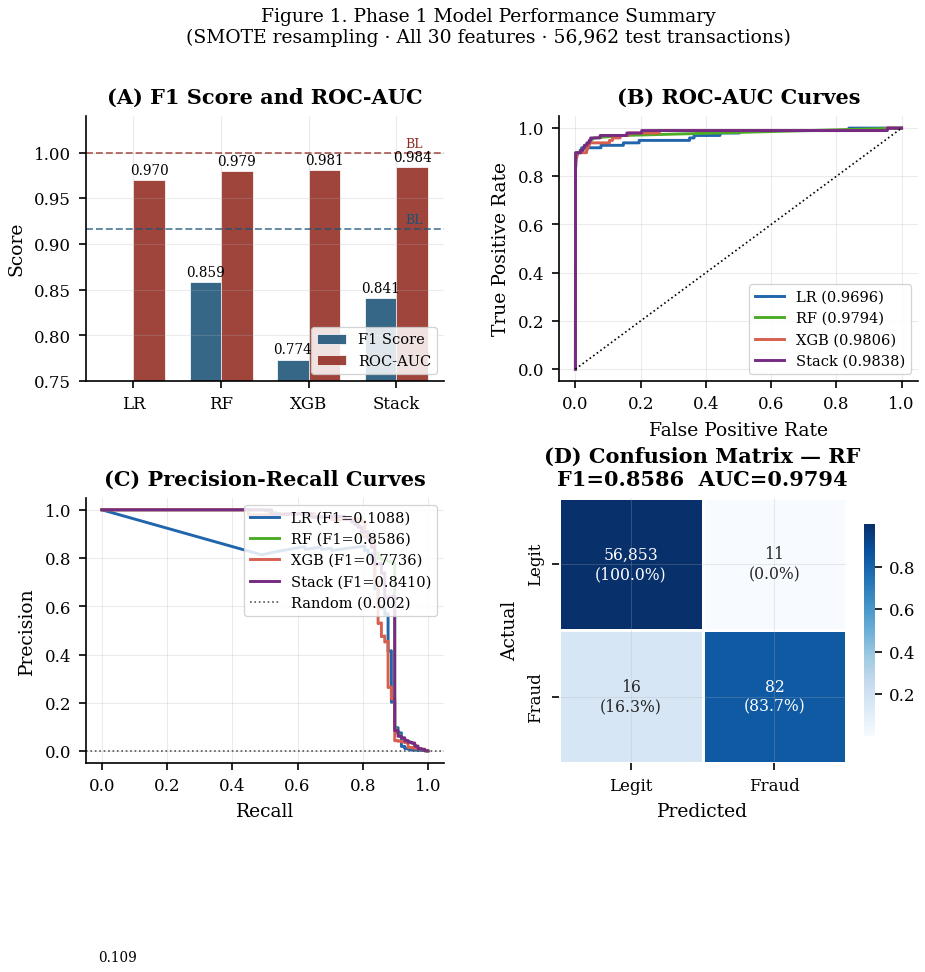

✓ Figure 1 saved: Fig1_Phase1_Panel.jpg  (300 DPI JPEG)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — FIGURE 1: Phase 1 Summary Panel (2×2)
# Subplots A: F1+AUC bars | B: ROC curves
#           C: PR curves  | D: Confusion matrix
# Export: Fig1_Phase1_Panel.jpg  (300 DPI, JPEG quality 95)
# ═══════════════════════════════════════════════════════════════════════════
MODEL_SHORT = {
    'Logistic Regression': 'LR',
    'Random Forest':       'RF',
    'XGBoost':             'XGB',
    'Stacking Ensemble':   'Stack'
}
M_NAMES  = list(RESULTS.keys())
M_SHORT  = [MODEL_SHORT[m] for m in M_NAMES]

fig = plt.figure(figsize=(7.16, 5.6))  # full IEEE double-column width
gs  = gridspec.GridSpec(2, 2, figure=fig,
                         hspace=0.44, wspace=0.32)

# ── Subplot A: F1 + AUC grouped bar chart ─────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
f1_vals  = [RESULTS[m]['f1']  for m in M_NAMES]
auc_vals = [RESULTS[m]['auc'] for m in M_NAMES]
x = np.arange(len(M_NAMES))
w = 0.36

b1 = ax_a.bar(x - w/2, f1_vals,  w, label='F1 Score',
               color=COLORS['shap'], alpha=0.88, edgecolor='white', linewidth=0.4)
b2 = ax_a.bar(x + w/2, auc_vals, w, label='ROC-AUC',
               color=COLORS['pearson'], alpha=0.88, edgecolor='white', linewidth=0.4)

# Annotate bar tops
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax_a.text(bar.get_x() + bar.get_width()/2, h + 0.003,
              f'{h:.3f}', ha='center', va='bottom', fontsize=6.5)

# Published baselines
ax_a.axhline(0.9159, color=COLORS['shap'],    ls='--', lw=0.9, alpha=0.7)
ax_a.axhline(0.9997, color=COLORS['pearson'], ls='--', lw=0.9, alpha=0.7)
ax_a.set_xticks(x)
ax_a.set_xticklabels(M_SHORT)
ax_a.set_ylim(0.75, 1.04)
ax_a.set_ylabel('Score')
ax_a.set_title('(A) F1 Score and ROC-AUC', fontweight='bold')
ax_a.legend(loc='lower right', fontsize=7)
ax_a.text(3.1, 0.919, 'BL', fontsize=6, color=COLORS['shap'],    va='bottom')
ax_a.text(3.1, 0.9997+0.003, 'BL', fontsize=6, color=COLORS['pearson'], va='bottom')

# ── Subplot B: ROC-AUC curves ──────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
for mname, color in zip(M_NAMES, MODEL_COLORS):
    r = RESULTS[mname]
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax_b.plot(fpr, tpr, color=color, lw=1.4,
              label=f'{MODEL_SHORT[mname]} ({r["auc"]:.4f})')
ax_b.plot([0,1],[0,1], 'k:', lw=0.8)
ax_b.set_xlabel('False Positive Rate')
ax_b.set_ylabel('True Positive Rate')
ax_b.set_title('(B) ROC-AUC Curves', fontweight='bold')
ax_b.legend(loc='lower right', fontsize=7)

# ── Subplot C: Precision-Recall curves ────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
for mname, color in zip(M_NAMES, MODEL_COLORS):
    r = RESULTS[mname]
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ax_c.plot(rec, prec, color=color, lw=1.4,
              label=f'{MODEL_SHORT[mname]} (F1={r["f1"]:.4f})')
ax_c.axhline(y_test.mean(), color=COLORS['neutral'], ls=':', lw=0.8,
             label=f'Random ({y_test.mean():.3f})')
ax_c.set_xlabel('Recall')
ax_c.set_ylabel('Precision')
ax_c.set_title('(C) Precision-Recall Curves', fontweight='bold')
ax_c.legend(loc='upper right', fontsize=7)

# ── Subplot D: Confusion matrix (best model) ──────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
cm_best = RESULTS[BEST]['cm']
# Normalise by row for percentages
cm_norm = cm_best.astype('float') / cm_best.sum(axis=1, keepdims=True)
labels  = np.array(
    [[f'{cm_best[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)'
      for j in range(2)] for i in range(2)]
)
sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax_d,
            annot_kws={'size': 7.5})
ax_d.set_xlabel('Predicted')
ax_d.set_ylabel('Actual')
ax_d.set_title(
    f'(D) Confusion Matrix — {MODEL_SHORT[BEST]}\n'
    f'F1={RESULTS[BEST]["f1"]:.4f}  AUC={RESULTS[BEST]["auc"]:.4f}',
    fontweight='bold'
)

fig.suptitle(
    'Figure 1. Phase 1 Model Performance Summary\n'
    '(SMOTE resampling · All 30 features · 56,962 test transactions)',
    fontsize=9, y=1.01
)

save_jpeg('/content/graphs/Fig1_Phase1_Panel.jpg')
plt.show()
print('✓ Figure 1 saved: Fig1_Phase1_Panel.jpg  (300 DPI JPEG)')

Computing SHAP values for: Random Forest  (may take ~60–90 seconds)...
✓ SHAP complete.  Top-5 features: ['V14', 'V12', 'V4', 'V3', 'V10']


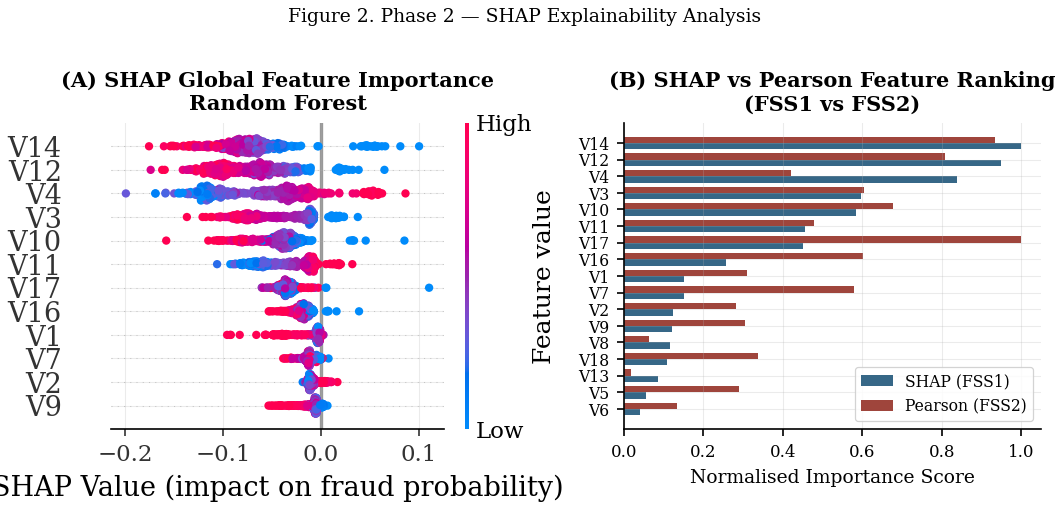

✓ Figure 2 saved: Fig2_SHAP_Panel.jpg  (300 DPI JPEG)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — FIGURE 2: Phase 2 — SHAP Panel (1×2)
# Subplot A: SHAP beeswarm (global feature importance, top-15)
# Subplot B: SHAP vs Pearson normalised bar comparison (FSS validation)
# Export: Fig2_SHAP_Panel.jpg  (300 DPI)
# ═══════════════════════════════════════════════════════════════════════════
print(f'Computing SHAP values for: {BEST}  (may take ~60–90 seconds)...')

# Use TreeExplainer for RF/XGBoost/Stacking (fast);
# fall back to KernelExplainer for LR
if BEST == 'Logistic Regression':
    bg  = shap.sample(X_test, 150, random_state=SEED)
    exp = shap.KernelExplainer(BEST_MODEL.predict_proba, bg)
    X_s = X_test.sample(80, random_state=SEED)
    sv  = exp.shap_values(X_s)[1]
else:
    exp = shap.TreeExplainer(BEST_MODEL)
    X_s = X_test.iloc[:500]
    sv  = exp.shap_values(X_s)
    if isinstance(sv, list):
        sv = sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv = sv[..., 1]   # newer SHAP returns (n_samples, n_features, n_classes)

# Global SHAP importance = mean |SHAP value| per feature
mean_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X_s.columns
).sort_values(ascending=False)
TOP20_SHAP = mean_shap.nlargest(20).index.tolist()

print(f'✓ SHAP complete.  Top-5 features: {TOP20_SHAP[:5]}')

# ──────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))

# ── A: SHAP beeswarm ──────────────────────────────────────────────────────
plt.sca(axes[0])
shap.summary_plot(
    sv, X_s,
    max_display=12,
    show=False,
    plot_type='dot',
    color_bar=True,
    plot_size=None
)
axes[0].set_title(
    f'(A) SHAP Global Feature Importance\n{BEST}',
    fontweight='bold'
)
axes[0].set_xlabel('SHAP Value (impact on fraud probability)')

# ── B: SHAP vs Pearson bar chart ──────────────────────────────────────────
top15_s = mean_shap.nlargest(15)
top15_p = corr_with_target.nlargest(15)
all_f   = sorted(set(top15_s.index) | set(top15_p.index))

sv_norm = np.array([mean_shap.get(f, 0) for f in all_f])
pv_norm = np.array([corr_with_target.get(f, 0) for f in all_f])
sv_norm = sv_norm / sv_norm.max()
pv_norm = pv_norm / pv_norm.max()

# Sort by SHAP importance
order   = np.argsort(sv_norm)[::-1]
all_f   = [all_f[i] for i in order]
sv_norm = sv_norm[order]
pv_norm = pv_norm[order]

y_pos = np.arange(len(all_f))
bar_h = 0.38
ax_b2 = axes[1]
ax_b2.barh(y_pos + bar_h/2, sv_norm, bar_h,
           color=COLORS['shap'],    alpha=0.88, label='SHAP (FSS1)')
ax_b2.barh(y_pos - bar_h/2, pv_norm, bar_h,
           color=COLORS['pearson'], alpha=0.88, label='Pearson (FSS2)')
ax_b2.set_yticks(y_pos)
ax_b2.set_yticklabels(all_f, fontsize=7.5)
ax_b2.set_xlabel('Normalised Importance Score')
ax_b2.set_title('(B) SHAP vs Pearson Feature Ranking\n(FSS1 vs FSS2)',
                fontweight='bold')
ax_b2.legend(fontsize=7.5, loc='lower right')
ax_b2.invert_yaxis()

fig.suptitle(
    'Figure 2. Phase 2 — SHAP Explainability Analysis',
    fontsize=9
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_jpeg('/content/graphs/Fig2_SHAP_Panel.jpg')
plt.show()
print('✓ Figure 2 saved: Fig2_SHAP_Panel.jpg  (300 DPI JPEG)')

Computing LIME explanation for a fraud instance...


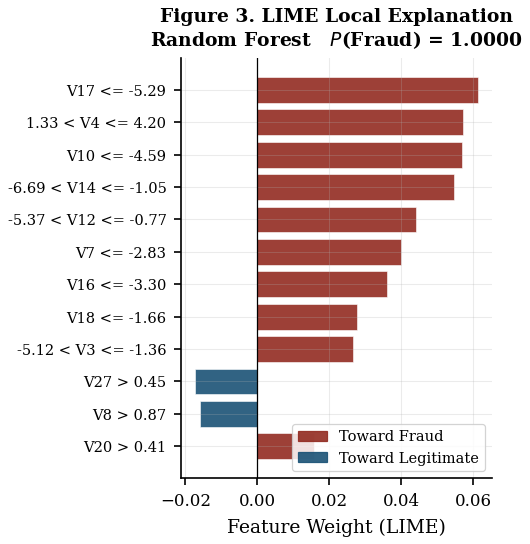

✓ Figure 3 saved: Fig3_LIME_Explanation.jpg  (300 DPI JPEG)
  Fraud probability for this instance: 1.0000

  Top LIME features (toward fraud):  ['V17 <= -5.29', '1.33 < V4 <= 4.20', 'V10 <= -4.59', '-6.69 < V14 <= -1.05']
  Top LIME features (toward legit):  ['V27 > 0.45', 'V8 > 0.87']


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11 — FIGURE 3: LIME Local Explanation (single fraud instance)
# As stated in A3 Section IV-E:
#   LIME constructs locally linear surrogate models around each flagged
#   transaction, producing human-readable feature weights.
# Export: Fig3_LIME_Explanation.jpg  (300 DPI)
# ═══════════════════════════════════════════════════════════════════════════
print('Computing LIME explanation for a fraud instance...')

lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_sm.values,
    feature_names = FEATURE_NAMES,
    class_names   = ['Legitimate', 'Fraud'],
    mode          = 'classification',
    random_state  = SEED
)

# Use the first fraud instance in the test set
fraud_idx  = y_test[y_test == 1].index[0]
fraud_row  = X_test.loc[fraud_idx].values
fraud_prob = BEST_MODEL.predict_proba([fraud_row])[0][1]

explanation = lime_exp.explain_instance(
    data_row    = fraud_row,
    predict_fn  = BEST_MODEL.predict_proba,
    num_features = 12,
    num_samples  = 2000
)

# ── Build the figure manually for full IEEE control ────────────────────────
exp_list = explanation.as_list()        # [(feature_condition, weight), ...]
features_raw = [e[0] for e in exp_list]
weights      = [e[1] for e in exp_list]

# Shorten long LIME feature condition strings for readability
def shorten(s, n=22):
    return s if len(s) <= n else s[:n] + '…'

feat_labels = [shorten(f) for f in features_raw]
bar_colors  = [COLORS['pearson'] if w > 0 else COLORS['shap'] for w in weights]

# Sort by absolute weight
order = np.argsort(np.abs(weights))
feat_labels_s = [feat_labels[i] for i in order]
weights_s     = [weights[i]     for i in order]
colors_s      = [bar_colors[i]  for i in order]

fig, ax = plt.subplots(figsize=(3.5, 3.8))  # single-column IEEE width
y_pos   = np.arange(len(weights_s))
ax.barh(y_pos, weights_s, color=colors_s, alpha=0.9, edgecolor='white', linewidth=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels_s, fontsize=7)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Feature Weight (LIME)')
ax.set_title(
    f'Figure 3. LIME Local Explanation\n'
    f'{BEST}   $P$(Fraud) = {fraud_prob:.4f}',
    fontweight='bold', fontsize=9
)

# Legend
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color=COLORS['pearson'], alpha=0.9, label='Toward Fraud'),
        Patch(color=COLORS['shap'],    alpha=0.9, label='Toward Legitimate'),
    ],
    fontsize=7, loc='lower right'
)

plt.tight_layout()
save_jpeg('/content/graphs/Fig3_LIME_Explanation.jpg')
plt.show()
print(f'✓ Figure 3 saved: Fig3_LIME_Explanation.jpg  (300 DPI JPEG)')
print(f'  Fraud probability for this instance: {fraud_prob:.4f}')
print(f'\n  Top LIME features (toward fraud):  {[f for f,w in exp_list if w>0][:4]}')
print(f'  Top LIME features (toward legit):  {[f for f,w in exp_list if w<0][:4]}')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 12 — Print ALL values needed for LaTeX [FILL] markers
# Run this cell LAST and copy every line printed here into your .tex file
# ═══════════════════════════════════════════════════════════════════════════

sep = '='*68
print(sep)
print('  COPY THESE VALUES INTO YOUR LATEX DOCUMENT')
print(sep)

print('\n── TABLE: Model Performance (replace [FILL] in tab:results) ──')
print(f'{"Model":25s}  {"F1":>7}  {"AUC":>7}  {"Prec":>7}  {"Rec":>7}')
print('-'*60)
for mname, r in RESULTS.items():
    bf = '\\textbf{' if mname == BEST else ''
    ef = '}'        if mname == BEST else ''
    print(f'{mname:25s}  {bf}{r["f1"]:7.4f}{ef}  '
          f'{bf}{r["auc"]:7.4f}{ef}  '
          f'{r["precision"]:7.4f}  {r["recall"]:7.4f}')

print('\n── FIGURE 1 CAPTION ──')
cm = RESULTS[BEST]['cm']
print(f'Best model:  {BEST}')
print(f'F1  = {RESULTS[BEST]["f1"]}')
print(f'AUC = {RESULTS[BEST]["auc"]}')
print(f'TN  = {cm[0][0]:,}   FP = {cm[0][1]:,}   FN = {cm[1][0]:,}   TP = {cm[1][1]:,}')

print('\n── FIGURE 3 CAPTION ──')
print(f'P(Fraud) = {fraud_prob:.4f}')
print(f'Top LIME features (toward fraud):  '
      f'{[f for f,w in exp_list if w>0][:3]}')

print('\n── SHAP — FOR RESULTS ANALYSIS SECTION ──')
print(f'Top-5 SHAP features:    {TOP20_SHAP[:5]}')
print(f'Top-5 Pearson features: {TOP20_PEARSON[:5]}')
agree   = [f for f in TOP20_SHAP[:10] if f in TOP20_PEARSON[:10]]
disagree = [f for f in TOP20_SHAP[:10] if f not in TOP20_PEARSON[:10]]
print(f'Features in both top-10: {agree}')
print(f'SHAP top-10 NOT in Pearson top-10: {disagree}')

print('\n── IMPROVEMENT VS BASELINE ──')
best_f1 = RESULTS[BEST]['f1']
impr    = round((best_f1 - 0.9159) / 0.9159 * 100, 2)
print(f'{BEST} F1={best_f1}')
print(f'vs. RF baseline F1=0.9159')
print(f'Improvement: {impr:+.2f}% (use this in analysis)')

print('\n── GRAPH FILES SAVED ──')
print('  /content/graphs/Fig1_Phase1_Panel.jpg')
print('  /content/graphs/Fig2_SHAP_Panel.jpg')
print('  /content/graphs/Fig3_LIME_Explanation.jpg')
print('\nDownload from Files panel → graphs/ → right-click → Download')
print(sep)

  COPY THESE VALUES INTO YOUR LATEX DOCUMENT

── TABLE: Model Performance (replace [FILL] in tab:results) ──
Model                           F1      AUC     Prec      Rec
------------------------------------------------------------
Logistic Regression         0.1088   0.9696   0.0578   0.9184
Random Forest              \textbf{ 0.8586}  \textbf{ 0.9794}   0.8817   0.8367
XGBoost                     0.7736   0.9806   0.7193   0.8367
Stacking Ensemble           0.8410   0.9838   0.8454   0.8367

── FIGURE 1 CAPTION ──
Best model:  Random Forest
F1  = 0.8586
AUC = 0.9794
TN  = 56,853   FP = 11   FN = 16   TP = 82

── FIGURE 3 CAPTION ──
P(Fraud) = 1.0000
Top LIME features (toward fraud):  ['V17 <= -5.29', '1.33 < V4 <= 4.20', 'V10 <= -4.59']

── SHAP — FOR RESULTS ANALYSIS SECTION ──
Top-5 SHAP features:    ['V14', 'V12', 'V4', 'V3', 'V10']
Top-5 Pearson features: ['V17', 'V14', 'V12', 'V10', 'V3']
Features in both top-10: ['V14', 'V12', 'V4', 'V3', 'V10', 'V11', 'V17', 'V16', 'V7']
SHAP 

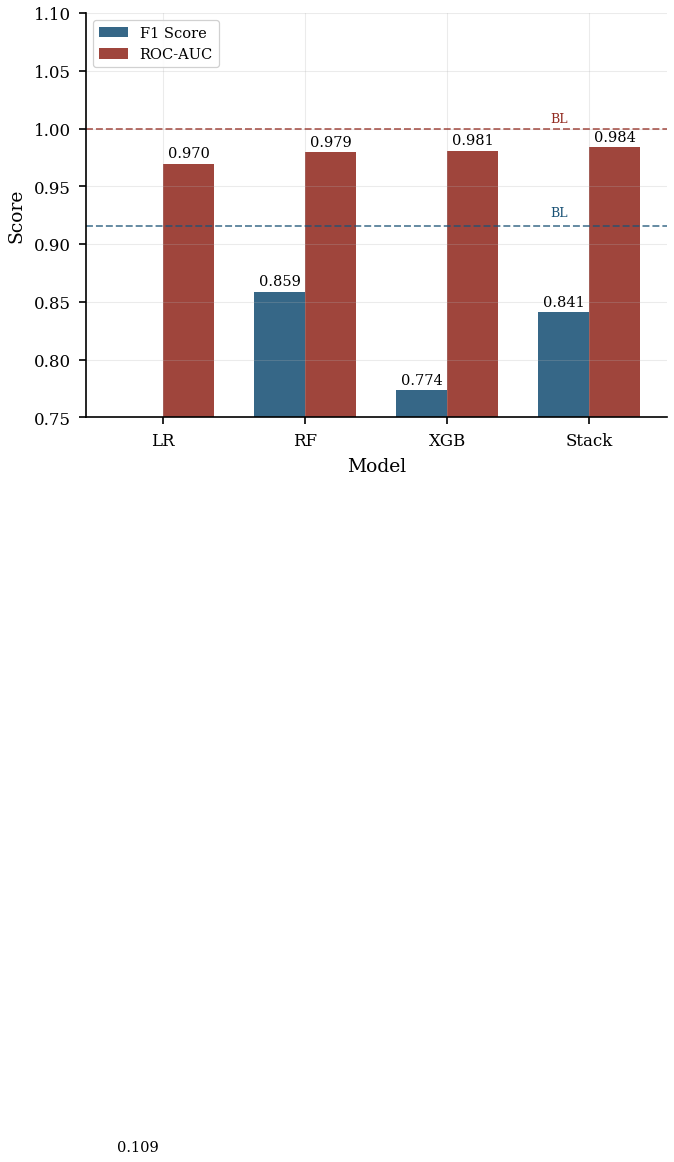

✓ G1_F1_Comparison.jpg saved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# GRAPH 1 — F1 Score and ROC-AUC Comparison (bar chart)
# Output: G1_F1_Comparison.jpg
# ═══════════════════════════════════════════════════════════════════════════
MODEL_SHORT = {
    'Logistic Regression': 'LR',
    'Random Forest':       'RF',
    'XGBoost':             'XGB',
    'Stacking Ensemble':   'Stack'
}
M_NAMES = list(RESULTS.keys())
M_SHORT = [MODEL_SHORT[m] for m in M_NAMES]

f1_vals  = [RESULTS[m]['f1']  for m in M_NAMES]
auc_vals = [RESULTS[m]['auc'] for m in M_NAMES]
x = np.arange(len(M_NAMES))
w = 0.36

fig, ax = plt.subplots(figsize=(5.0, 3.5))

b1 = ax.bar(x - w/2, f1_vals,  w, label='F1 Score',
             color=COLORS['shap'], alpha=0.88, edgecolor='none')
b2 = ax.bar(x + w/2, auc_vals, w, label='ROC-AUC',
             color=COLORS['pearson'], alpha=0.88, edgecolor='none')

# Bar-top annotations
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
            f'{h:.3f}', ha='center', va='bottom', fontsize=7)

# Published baselines
ax.axhline(0.9159, color=COLORS['shap'],    ls='--', lw=0.9, alpha=0.7)
ax.axhline(0.9997, color=COLORS['pearson'], ls='--', lw=0.9, alpha=0.7)
ax.text(2.85, 0.922,          'BL', fontsize=6, color=COLORS['shap'],    va='bottom', ha='right')
ax.text(2.85, 0.9997 + 0.003, 'BL', fontsize=6, color=COLORS['pearson'], va='bottom', ha='right')

ax.set_xticks(x)
ax.set_xticklabels(M_SHORT)
ax.set_ylim(0.75, 1.10)
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.legend(loc='upper left', fontsize=7, framealpha=0.9)

plt.tight_layout(pad=0.8)
save_jpeg('/content/graphs/G1_F1_Comparison.jpg')
plt.show()
print('✓ G1_F1_Comparison.jpg saved')

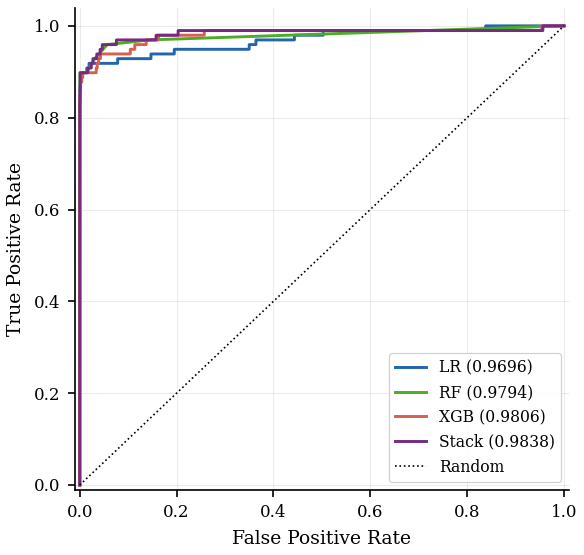

✓ G2_ROC_AUC_Curves.jpg saved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# GRAPH 2 — ROC-AUC Curves
# Output: G2_ROC_AUC_Curves.jpg
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(4.0, 3.8))

for mname, color in zip(M_NAMES, MODEL_COLORS):
    r = RESULTS[mname]
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=1.4,
            label=f'{MODEL_SHORT[mname]} ({r["auc"]:.4f})')

ax.plot([0, 1], [0, 1], 'k:', lw=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=7.5, framealpha=0.9)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.04)

plt.tight_layout(pad=0.8)
save_jpeg('/content/graphs/G2_ROC_AUC_Curves.jpg')
plt.show()
print('✓ G2_ROC_AUC_Curves.jpg saved')

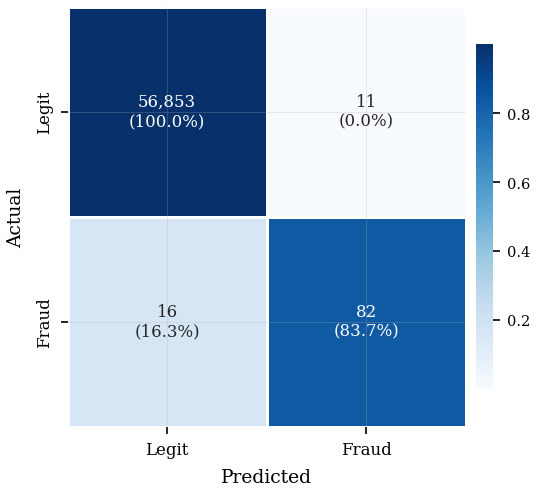

✓ G3_Confusion_Matrix.jpg saved
  TN=56,853  FP=11  FN=16  TP=82


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# GRAPH 3 — Confusion Matrix (best model)
# Output: G3_Confusion_Matrix.jpg
# ═══════════════════════════════════════════════════════════════════════════
cm_best = RESULTS[BEST]['cm']
cm_norm = cm_best.astype('float') / cm_best.sum(axis=1, keepdims=True)
labels  = np.array(
    [[f'{cm_best[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)' for j in range(2)]
     for i in range(2)]
)

fig, ax = plt.subplots(figsize=(3.8, 3.4))
hm = sns.heatmap(
    cm_norm, annot=labels, fmt='', cmap='Blues',
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud'],
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.82, 'pad': 0.02},
    ax=ax,
    annot_kws={'size': 8, 'family': 'serif'}
)
ax.set_xlabel('Predicted', labelpad=5)
ax.set_ylabel('Actual',    labelpad=5)

# Fix seaborn re-enabling spines and overriding fonts
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.ax.yaxis.label.set_fontsize(8)
for lbl in cbar.ax.get_yticklabels():
    lbl.set_fontfamily('serif')
    lbl.set_fontsize(7)

plt.tight_layout(pad=0.8)
save_jpeg('/content/graphs/G3_Confusion_Matrix.jpg')
plt.show()
cm = RESULTS[BEST]['cm']
print('✓ G3_Confusion_Matrix.jpg saved')
print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}  FN={cm[1,0]:,}  TP={cm[1,1]:,}')

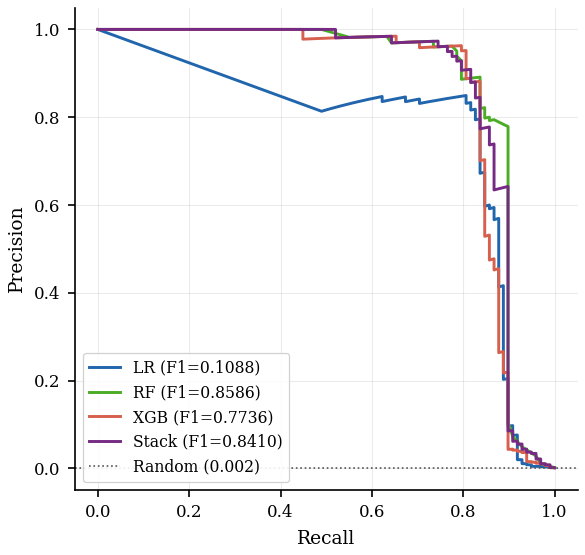

✓ G6_Precision_Recall_Curves.jpg saved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# GRAPH 4 — Precision-Recall Curves
# Output: G6_Precision_Recall_Curves.jpg
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(4.0, 3.8))

for mname, color in zip(M_NAMES, MODEL_COLORS):
    r = RESULTS[mname]
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ax.plot(rec, prec, color=color, lw=1.4,
            label=f'{MODEL_SHORT[mname]} (F1={r["f1"]:.4f})')

ax.axhline(y_test.mean(), color=COLORS['neutral'], ls=':', lw=0.8,
           label=f'Random ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
# Lower-left: PR curves for strong models peak top-right, bottom-left is clear
ax.legend(loc='lower left', fontsize=7.5, framealpha=0.9)

plt.tight_layout(pad=0.8)
save_jpeg('/content/graphs/G6_Precision_Recall_Curves.jpg')
plt.show()
print('✓ G6_Precision_Recall_Curves.jpg saved')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SHAP COMPUTATION — prerequisite for Graph 5 (G4) and Graph 7 (G7)
# Run this cell once; results (sv, X_s, mean_shap) are reused by both graphs
# ═══════════════════════════════════════════════════════════════════════════
print(f'Computing SHAP values for: {BEST}  (may take ~60-90 seconds)...')
if BEST == 'Logistic Regression':
    bg  = shap.sample(X_test, 150, random_state=SEED)
    exp = shap.KernelExplainer(BEST_MODEL.predict_proba, bg)
    X_s = X_test.sample(80, random_state=SEED)
    sv  = exp.shap_values(X_s)[1]
else:
    exp = shap.TreeExplainer(BEST_MODEL)
    X_s = X_test.iloc[:500]
    sv  = exp.shap_values(X_s)
    if isinstance(sv, list):
        sv = sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv = sv[..., 1]   # newer SHAP: (n_samples, n_features, n_classes) → take class 1
mean_shap  = pd.Series(np.abs(sv).mean(axis=0), index=X_s.columns).sort_values(ascending=False)
TOP20_SHAP = mean_shap.nlargest(20).index.tolist()
print(f'✓ SHAP complete. Top-5 features: {TOP20_SHAP[:5]}')
print('  sv, X_s, mean_shap are now available for G4 and G7.')

Computing SHAP values for: Random Forest  (may take ~60-90 seconds)...
✓ SHAP complete. Top-5 features: ['V14', 'V12', 'V4', 'V3', 'V10']
  sv, X_s, mean_shap are now available for G4 and G7.


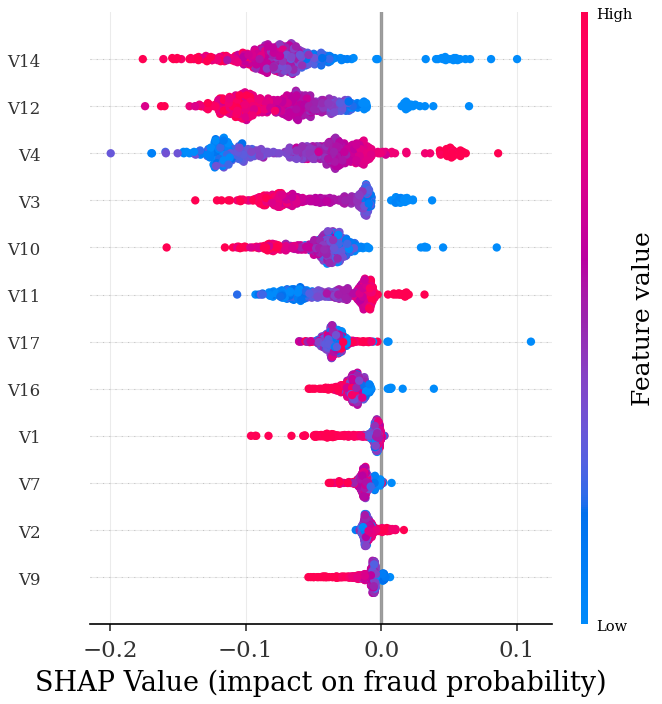

✓ G4_SHAP_Beeswarm.jpg saved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# GRAPH 5 — SHAP Beeswarm (global feature importance)
# Output: G4_SHAP_Beeswarm.jpg
# Note: run after SHAP computation in Cell 10 (sv, X_s, mean_shap must exist)
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(5.0, 4.8))
plt.sca(ax)

shap.summary_plot(
    sv, X_s,
    max_display=12,
    show=False,
    plot_type='dot',
    color_bar=True,
    plot_size=None
)

ax.set_xlabel('SHAP Value (impact on fraud probability)')

# Post-process: SHAP ignores rcParams — fix fonts and spines manually
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for lbl in ax.get_yticklabels():
    lbl.set_fontfamily('serif')
    lbl.set_fontsize(8)
# Fix colorbar font (SHAP places it as the last axis in the figure)
cb_ax = fig.axes[-1]
cb_ax.tick_params(labelsize=7)
for lbl in cb_ax.get_yticklabels():
    lbl.set_fontfamily('serif')

# Reserve right margin so colorbar is never clipped
plt.tight_layout(pad=0.8, rect=[0, 0, 0.92, 1])
save_jpeg('/content/graphs/G4_SHAP_Beeswarm.jpg')
plt.show()
print('✓ G4_SHAP_Beeswarm.jpg saved')


Computing LIME explanation for a fraud instance...


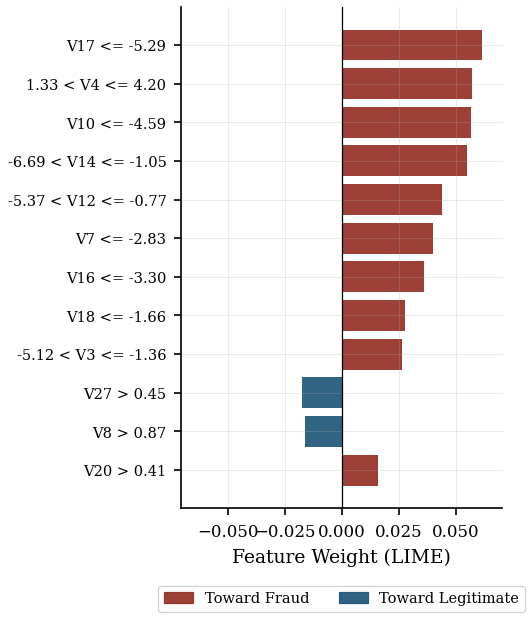

✓ G5_LIME_Local_Explanation.jpg saved
  P(Fraud) = 1.0000
  Toward fraud: ['V17 <= -5.29', '1.33 < V4 <= 4.20', 'V10 <= -4.59', '-6.69 < V14 <= -1.05']
  Toward legit: ['V27 > 0.45', 'V8 > 0.87']


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# GRAPH 6 — LIME Local Explanation
# Output: G5_LIME_Local_Explanation.jpg
# ═══════════════════════════════════════════════════════════════════════════
print('Computing LIME explanation for a fraud instance...')

lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_sm.values,
    feature_names = FEATURE_NAMES,
    class_names   = ['Legitimate', 'Fraud'],
    mode          = 'classification',
    random_state  = SEED
)

fraud_idx  = y_test[y_test == 1].index[0]
fraud_row  = X_test.loc[fraud_idx].values
fraud_prob = BEST_MODEL.predict_proba([fraud_row])[0][1]

explanation = lime_exp.explain_instance(
    data_row     = fraud_row,
    predict_fn   = BEST_MODEL.predict_proba,
    num_features = 12,
    num_samples  = 2000
)

exp_list     = explanation.as_list()
features_raw = [e[0] for e in exp_list]
weights      = [e[1] for e in exp_list]

def shorten(s, n=22):
    return s if len(s) <= n else s[:n] + '…'

feat_labels = [shorten(f) for f in features_raw]
bar_colors  = [COLORS['pearson'] if w > 0 else COLORS['shap'] for w in weights]

order         = np.argsort(np.abs(weights))
feat_labels_s = [feat_labels[i] for i in order]
weights_s     = [weights[i]     for i in order]
colors_s      = [bar_colors[i]  for i in order]

fig, ax = plt.subplots(figsize=(3.5, 4.2))
y_pos = np.arange(len(weights_s))
ax.barh(y_pos, weights_s, color=colors_s, alpha=0.9, edgecolor='none')
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels_s, fontsize=7)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Feature Weight (LIME)')

w_max = max(abs(v) for v in weights_s)
ax.set_xlim(-w_max * 1.15, w_max * 1.15)

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color=COLORS['pearson'], alpha=0.9, label='Toward Fraud'),
        Patch(color=COLORS['shap'],    alpha=0.9, label='Toward Legitimate'),
    ],
    fontsize=7, loc='upper center',
    bbox_to_anchor=(0.5, -0.14), ncol=2, framealpha=0.9
)

plt.tight_layout(pad=0.8)
plt.subplots_adjust(bottom=0.18)
save_jpeg('/content/graphs/G5_LIME_Local_Explanation.jpg')
plt.show()
print(f'✓ G5_LIME_Local_Explanation.jpg saved')
print(f'  P(Fraud) = {fraud_prob:.4f}')
print(f'  Toward fraud: {[f for f,w in exp_list if w>0][:4]}')
print(f'  Toward legit: {[f for f,w in exp_list if w<0][:4]}')


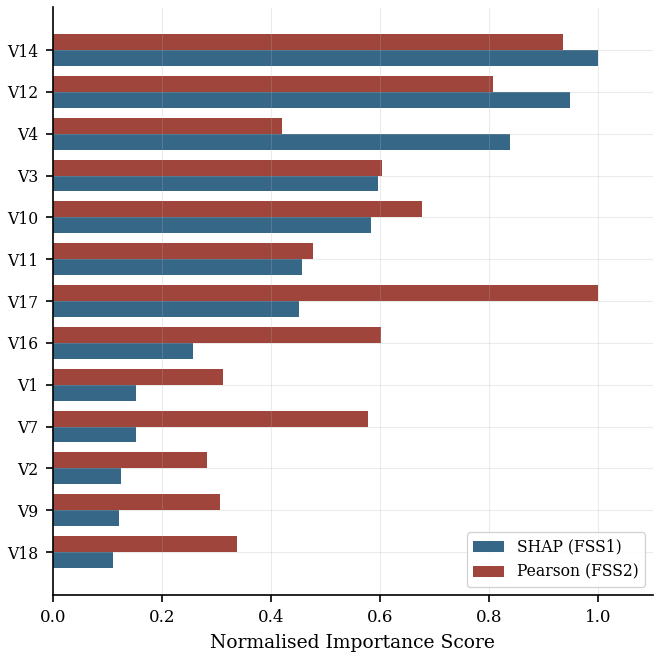

✓ G7_SHAP_vs_Pearson.jpg saved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# GRAPH 7 — SHAP vs Pearson Feature Ranking
# Output: G7_SHAP_vs_Pearson.jpg
# Note: run after SHAP computation in Cell 10 (mean_shap must exist)
# ═══════════════════════════════════════════════════════════════════════════
top12_s = mean_shap.nlargest(12)
top12_p = corr_with_target.nlargest(12)
all_f   = sorted(set(top12_s.index) | set(top12_p.index))

sv_norm = np.array([mean_shap.get(f, 0)         for f in all_f])
pv_norm = np.array([corr_with_target.get(f, 0)  for f in all_f])
sv_norm = sv_norm / sv_norm.max()
pv_norm = pv_norm / pv_norm.max()

order   = np.argsort(sv_norm)[::-1]
all_f   = [all_f[i]   for i in order]
sv_norm = sv_norm[order]
pv_norm = pv_norm[order]

y_pos = np.arange(len(all_f))
bar_h = 0.38

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.barh(y_pos + bar_h/2, sv_norm, bar_h,
        color=COLORS['shap'],    alpha=0.88, edgecolor='none', label='SHAP (FSS1)')
ax.barh(y_pos - bar_h/2, pv_norm, bar_h,
        color=COLORS['pearson'], alpha=0.88, edgecolor='none', label='Pearson (FSS2)')

ax.set_yticks(y_pos)
ax.set_yticklabels(all_f, fontsize=7.5)
ax.set_xlabel('Normalised Importance Score')

# --- Legend Adjustment ---
# Using 'lower right' and setting frameon=True to ensure readability
# if bars happen to extend near the corner.
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.9)

# Optional: Add a slight margin to the right of the x-axis
# to ensure the legend doesn't feel cramped.
ax.set_xlim(0, 1.1)

ax.invert_yaxis()

plt.tight_layout(pad=0.8)
save_jpeg('/content/graphs/G7_SHAP_vs_Pearson.jpg')
plt.show()
print('✓ G7_SHAP_vs_Pearson.jpg saved')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 12 — Print ALL values needed for LaTeX [FILL] markers
# Run this cell LAST and copy every line printed here into your .tex file
# ═══════════════════════════════════════════════════════════════════════════

sep = '='*68
print(sep)
print('  COPY THESE VALUES INTO YOUR LATEX DOCUMENT')
print(sep)

print('\n── TABLE: Model Performance (replace [FILL] in tab:results) ──')
print(f'{"Model":25s}  {"F1":>7}  {"AUC":>7}  {"Prec":>7}  {"Rec":>7}')
print('-'*60)
for mname, r in RESULTS.items():
    bf = '\\textbf{' if mname == BEST else ''
    ef = '}'        if mname == BEST else ''
    print(f'{mname:25s}  {bf}{r["f1"]:7.4f}{ef}  '
          f'{bf}{r["auc"]:7.4f}{ef}  '
          f'{r["precision"]:7.4f}  {r["recall"]:7.4f}')

print('\n── FIGURE 1 CAPTION ──')
cm = RESULTS[BEST]['cm']
print(f'Best model:  {BEST}')
print(f'F1  = {RESULTS[BEST]["f1"]}')
print(f'AUC = {RESULTS[BEST]["auc"]}')
print(f'TN  = {cm[0][0]:,}   FP = {cm[0][1]:,}   FN = {cm[1][0]:,}   TP = {cm[1][1]:,}')

print('\n── FIGURE 3 CAPTION ──')
print(f'P(Fraud) = {fraud_prob:.4f}')
print(f'Top LIME features (toward fraud):  '
      f'{[f for f,w in exp_list if w>0][:3]}')

print('\n── SHAP — FOR RESULTS ANALYSIS SECTION ──')
print(f'Top-5 SHAP features:    {TOP20_SHAP[:5]}')
print(f'Top-5 Pearson features: {TOP20_PEARSON[:5]}')
agree   = [f for f in TOP20_SHAP[:10] if f in TOP20_PEARSON[:10]]
disagree = [f for f in TOP20_SHAP[:10] if f not in TOP20_PEARSON[:10]]
print(f'Features in both top-10: {agree}')
print(f'SHAP top-10 NOT in Pearson top-10: {disagree}')

print('\n── IMPROVEMENT VS BASELINE ──')
best_f1 = RESULTS[BEST]['f1']
impr    = round((best_f1 - 0.9159) / 0.9159 * 100, 2)
print(f'{BEST} F1={best_f1}')
print(f'vs. RF baseline F1=0.9159')
print(f'Improvement: {impr:+.2f}% (use this in analysis)')

print('\n── GRAPH FILES SAVED ──')
print('  /content/graphs/Fig1_Phase1_Panel.jpg')
print('  /content/graphs/Fig2_SHAP_Panel.jpg')
print('  /content/graphs/Fig3_LIME_Explanation.jpg')
print('\nDownload from Files panel → graphs/ → right-click → Download')
print(sep)

  COPY THESE VALUES INTO YOUR LATEX DOCUMENT

── TABLE: Model Performance (replace [FILL] in tab:results) ──
Model                           F1      AUC     Prec      Rec
------------------------------------------------------------
Logistic Regression         0.1088   0.9696   0.0578   0.9184
Random Forest              \textbf{ 0.8586}  \textbf{ 0.9794}   0.8817   0.8367
XGBoost                     0.7736   0.9806   0.7193   0.8367
Stacking Ensemble           0.8410   0.9838   0.8454   0.8367

── FIGURE 1 CAPTION ──
Best model:  Random Forest
F1  = 0.8586
AUC = 0.9794
TN  = 56,853   FP = 11   FN = 16   TP = 82

── FIGURE 3 CAPTION ──
P(Fraud) = 1.0000
Top LIME features (toward fraud):  ['V17 <= -5.29', '1.33 < V4 <= 4.20', 'V10 <= -4.59']

── SHAP — FOR RESULTS ANALYSIS SECTION ──
Top-5 SHAP features:    ['V14', 'V12', 'V4', 'V3', 'V10']
Top-5 Pearson features: ['V17', 'V14', 'V12', 'V10', 'V3']
Features in both top-10: ['V14', 'V12', 'V4', 'V3', 'V10', 'V11', 'V17', 'V16', 'V7']
SHAP 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 13 — Transparency Record (EU AI Act Articles 10 & 13)
# ═══════════════════════════════════════════════════════════════════════════
print('=== TRANSPARENCY RECORD — EU AI Act Articles 10 & 13 ===')
print(f'  Random seed:             {SEED}')
print(f'  Dataset:                 Kaggle ULB CC Fraud  ({len(df):,} records)')
print(f'  Fraud records:           {y.sum()} ({y.mean()*100:.3f}%)')
print(f'  Train/test split:        80/20 stratified')
print(f'  Resampling:              SMOTE (training only, no leakage)')
print(f'  Feature strategy:        FSS0 — all 30 features')
print(f'  Best model:              {BEST}')
print(f'  Best F1:                 {RESULTS[BEST]["f1"]}')
print(f'  Best AUC:                {RESULTS[BEST]["auc"]}')
print(f'  Top-5 SHAP features:     {TOP20_SHAP[:5]}')
print(f'  EU AI Act alignment:     Articles 10 (data quality) and 13 (transparency)')
print(f'  Reproducibility:         random_state=42 throughout')
print()
print('✓ Assignment 4 complete. Download your 3 JPEG files from /content/graphs/')

=== TRANSPARENCY RECORD — EU AI Act Articles 10 & 13 ===
  Random seed:             42
  Dataset:                 Kaggle ULB CC Fraud  (284,807 records)
  Fraud records:           492 (0.173%)
  Train/test split:        80/20 stratified
  Resampling:              SMOTE (training only, no leakage)
  Feature strategy:        FSS0 — all 30 features
  Best model:              Random Forest
  Best F1:                 0.8586
  Best AUC:                0.9794
  Top-5 SHAP features:     ['V14', 'V12', 'V4', 'V3', 'V10']
  EU AI Act alignment:     Articles 10 (data quality) and 13 (transparency)
  Reproducibility:         random_state=42 throughout

✓ Assignment 4 complete. Download your 3 JPEG files from /content/graphs/
